# Client demo

Demonstrate the use of the Client (Assetto Corsa Sim interface) without the OpenAI Gym interface layer.

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import sys
import os
import numpy as np
import pandas as pd
import glob as glob
import time
import pickle
from omegaconf import OmegaConf

# add custom paths
sys.path.extend([os.path.abspath('./assetto_corsa_gym')])
import AssettoCorsaEnv.assettoCorsa as assettoCorsa

# Configure the logging system
import logging
logger = logging.getLogger(__name__)
logging.basicConfig(
    level=logging.INFO,  # Set the logging level (DEBUG, INFO, WARNING, ERROR, CRITICAL)
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',  # Format of the log messages
    datefmt='%Y-%m-%d %H:%M:%S',  # Format of the timestamp
)


# load config file

In [2]:
config = OmegaConf.load("config.yml")
client = assettoCorsa.make_client_only(config.AssettoCorsa)

# Show static info

In [3]:
static_info = client.simulation_management.get_static_info()
ac_mod_config = client.simulation_management.get_config()

logger.info("Static info:")
for i in static_info:
    logger.info(f"{i}: {static_info[i]}")
logger.info("AC Mod config:")
for i in ac_mod_config:
    logger.info(f"{i}: {ac_mod_config[i]}")


INFO:__main__:Static info:
INFO:__main__:TrackName: monza
INFO:__main__:CAR_TRACK: 1.6651489335363776
INFO:__main__:CarName: bmw_z4_gt3
INFO:__main__:penaltiesEnabled: 1
INFO:__main__:TyreContactPoint_FL: [-183.1895294189453, -7.399168014526367, 166.10791015625]
INFO:__main__:WindDirection: 0
INFO:__main__:isCarInPitlane: 0
INFO:__main__:CAR_WHEELBASE: 2.5098537370533442
INFO:__main__:isCarInPit: 0
INFO:__main__:TyreContactPoint_RL: [-183.45574951171875, -7.413916110992432, 168.6035614013672]
INFO:__main__:TyreContactPoint_FR: [-181.57603454589844, -7.378563404083252, 166.2660369873047]
INFO:__main__:TrackLength: 5758.66064453125
INFO:__main__:TyreContactPoint_RR: [-181.7986602783203, -7.392418384552002, 168.76577758789062]
INFO:__main__:autoShifterOn: 1
INFO:__main__:CAR_WHEEL_R: [0.3400000035762787, 0.3400000035762787, 0.35249999165534973, 0.35249999165534973]
INFO:__main__:TrackConfiguration: 
INFO:__main__:LastSplits: [0, 0, 0]
INFO:__main__:WindSpeed: 10
INFO:__main__:WorldPositio

# Test gear shift

In [4]:
# test gear shifting
client.controls.set_controls(0,-1,1, enable_gear_shift=True, shift_up=True)
client.controls.apply_local_controls()
time.sleep(0.01)
client.controls.set_controls(0,-1,1, enable_gear_shift=True, shift_up=False)
client.controls.apply_local_controls()

time.sleep(1.0)
client.controls.set_controls(0,-1,1, enable_gear_shift=True, shift_down=True)
client.controls.apply_local_controls()
time.sleep(0.01)
client.controls.set_controls(0,-1,1, enable_gear_shift=True, shift_down=False)
client.controls.apply_local_controls()

# Apply actions and recover the car

In [5]:
states = []

client.reset()

# shift up
client.controls.set_controls(0,-1,1, enable_gear_shift=True, shift_up=True)
client.controls.apply_local_controls()
time.sleep(0.01)
client.controls.set_controls(0,-1,1, enable_gear_shift=True, shift_up=False)
client.controls.apply_local_controls()

for i in range(100):
    if i % 2 == 0:
        steer = .1
    else:
        steer = -.1
    client.controls.set_controls(steer=steer, acc=0.5, brake=-1.)
    client.respond_to_server()
    state = client.step_sim()
    states.append(state.copy())
    time.sleep(0.01)

client.controls.set_defaults()
client.respond_to_server()
client.simulation_management.send_reset()
client.close()

INFO:AssettoCorsaEnv.ac_client:sending reset to simulation management server
INFO:AssettoCorsaEnv.ac_client:AC Client. Listening at host: localhost port: 2345
INFO:AssettoCorsaEnv.ac_client:Client connected on 2345
INFO:AssettoCorsaEnv.ac_client:sending reset to simulation management server


# Plot states

In [6]:
df = pd.DataFrame(states)
df.columns

Index(['done', 'packetId', 'pitch', 'steps', 'tyreContactHeading_RL_x',
       'tyre_loaded_radius', 'BestLap', 'rl_damper_linear_potentiometer',
       'isInPit', 'Dy_fr', 'RPM', 'fr_tire_pressure',
       'fr_damper_linear_potentiometer', 'Mz', 'fr_tire_temperature_core',
       'yaw', 'accelX', 'accelY', 'speed', 'velocity_y',
       'rl_tire_temperature_core', 'rr_damper_linear_potentiometer',
       'steerAngle', 'brakeStatus', 'wheel_speed_rl', 'rl_tire_pressure',
       'roll', 'cgHeight', 'penaltyTime', 'LastFF', 'LapCount',
       'local_velocity_z', 'wheel_speed_fl', 'local_velocity_y',
       'wheel_speed_fr', 'numberOfTyresOut', 'tyres_load',
       'angular_velocity_y', 'angular_velocity_x', 'NormalizedSplinePosition',
       'rr_tire_pressure', 'SlipAngle_fr', 'tyre_slip_ratio_fr', 'accStatus',
       'fl_tire_pressure', 'tyreContactHeading_RR_x', 'NdSlip',
       'tyreContactHeading_RR_z', 'tyreContactHeading_RR_y', 'iLastTime',
       'rl_wheel_load', 'tyre_slip_ratio_f

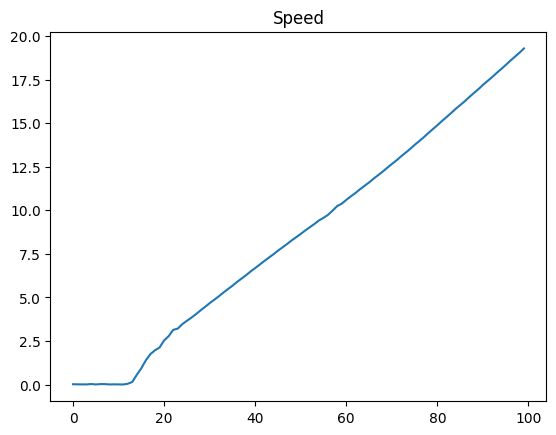

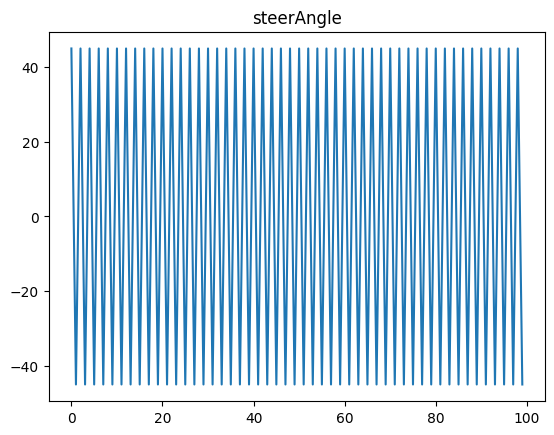

In [7]:
plt.title("Speed")
plt.plot(df.speed)
plt.show()

plt.title("steerAngle")
plt.plot(df.steerAngle)
plt.show()